# Importing Required Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

# Loading the Data

In [3]:
import pandas as pd
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
pima = pd.read_csv(url, header=None, names=col_names)
pima.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Feature Selection

In [4]:
feature_cols = ['pregnant', 'insulin', 'bmi', 'age', 'glucose', 'bp', 'pedigree']
X = pima[feature_cols]
y = pima.label

# Splitting Data into Training and Testing Sets

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Building and Training the Decision Tree Model

In [7]:
clf = DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Evaluating the Model

In [8]:
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 68.40%


# Visualizing Decision Trees

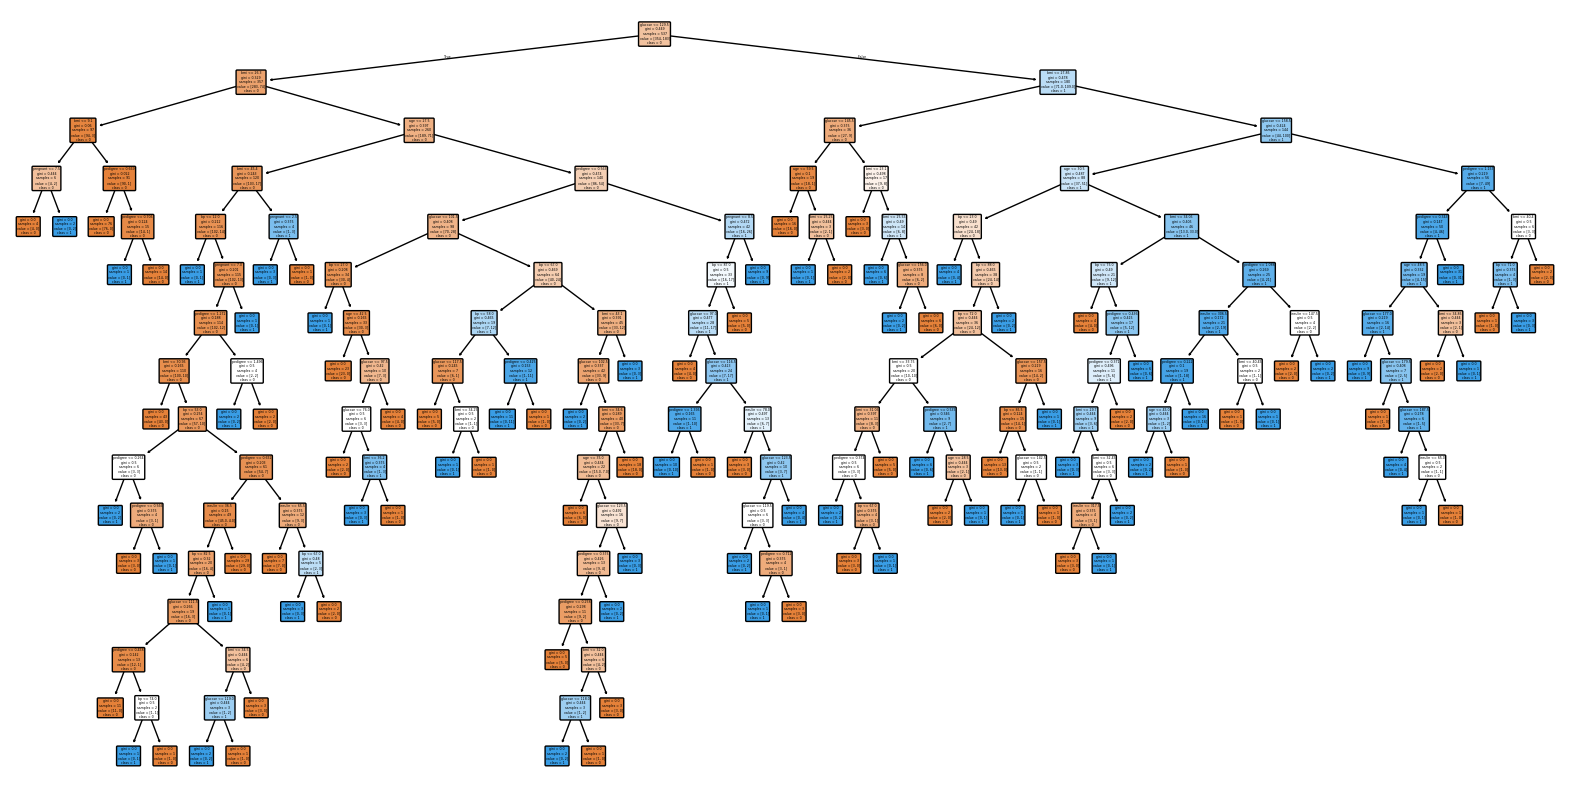

In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(clf, 
          feature_names=feature_cols,  
          class_names=['0', '1'],      
          filled=True,                 
          rounded=True)                
plt.show()

# Optimizing Decision Tree Performance

In [10]:
clf_optimized = DecisionTreeClassifier(criterion="entropy", max_depth=3)
clf_optimized = clf_optimized.fit(X_train, y_train)
y_pred_optimized = clf_optimized.predict(X_test)
accuracy_opt = metrics.accuracy_score(y_test, y_pred_optimized)
print(f"Optimized Model Accuracy: {accuracy_opt * 100:.2f}%")

Optimized Model Accuracy: 77.06%


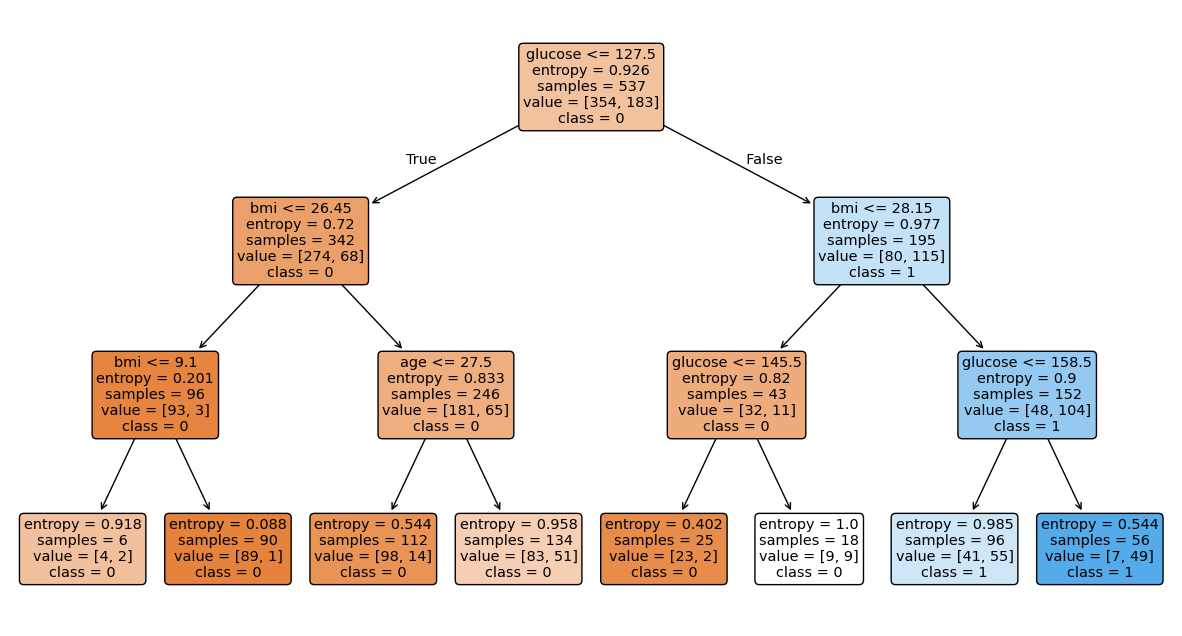

In [11]:
plt.figure(figsize=(15,8))
plot_tree(clf_optimized, 
          feature_names=feature_cols, 
          class_names=['0', '1'], 
          filled=True, 
          rounded=True)

plt.show()